<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/ENERGY_FORECASTING_(Relu_Version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Program Training (ReLU Version) Start
Hello, Dody Suhendra (6022251073) !
The current time is: 2026-06-14 15:30:39
Data windowing was successful
Model with ReLU created

Memulai training model ReLU...
Epoch 1/1000
10/10 - 11s - 1s/step - loss: 0.6567 - mae: 1.0500 - val_loss: 0.3582 - val_mae: 0.7294 - learning_rate: 0.0100
Epoch 2/1000
10/10 - 1s - 89ms/step - loss: 0.2843 - mae: 0.6292 - val_loss: 0.3318 - val_mae: 0.6973 - learning_rate: 0.0100
Epoch 3/1000
10/10 - 1s - 78ms/step - loss: 0.1899 - mae: 0.4988 - val_loss: 0.3318 - val_mae: 0.6835 - learning_rate: 0.0100
Epoch 4/1000
10/10 - 1s - 77ms/step - loss: 0.1917 - mae: 0.5018 - val_loss: 0.3491 - val_mae: 0.7028 - learning_rate: 0.0100
Epoch 5/1000
10/10 - 1s - 76ms/step - loss: 0.1446 - mae: 0.4284 - val_loss: 0.3527 - val_mae: 0.6998 - learning_rate: 0.0100
Epoch 6/1000
10/10 - 1s - 77ms/step - loss: 0.1320 - mae: 0.4080 - val_loss: 0.3431 - val_mae: 0.6905 - learning_rate: 0.0100
Epoch 7/1000
10/10 - 1s - 77ms/step - loss: 

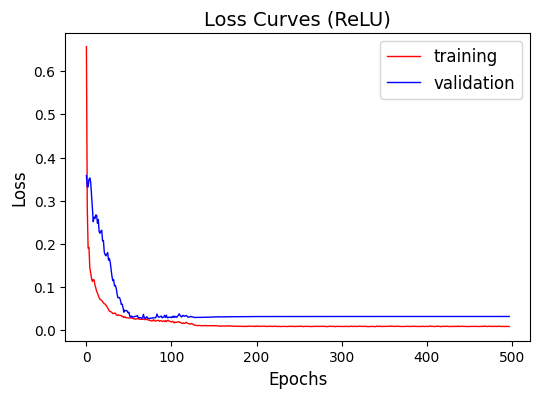

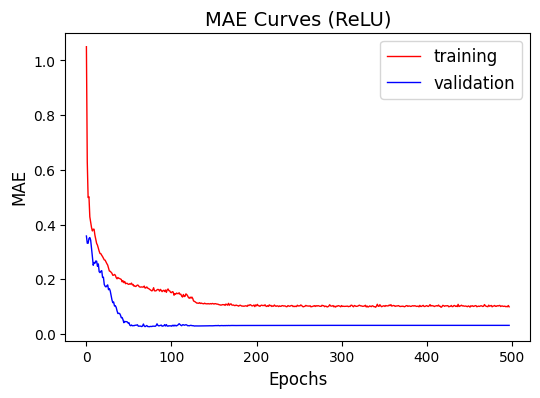

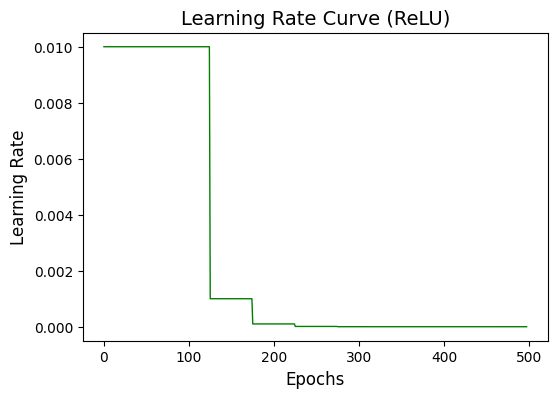

Model saved as: Energy Forecasting_ReLU.keras
End of program


In [1]:
# =====================================================================
# PROGRAM TRAINING ENERGY FORECASTING - ARSITEKTUR REVISI (ReLU VERSION)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from datetime import datetime
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization

print('Program Training (ReLU Version) Start')

# --- LANGKAH 1: IDENTITAS & LOAD DATA ---
student_name = 'Dody Suhendra'
student_id = '6022251073'
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f'Hello, {student_name} ({student_id}) !')
print(f'The current time is: {current_time}')

# Membaca file dataset
data_filename = 'AEP_hourly.csv'
df = pd.read_csv(data_filename)

# --- LANGKAH 2: FILTERING & SUB-SAMPLING ---
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values(by='Datetime')
df = df[df['Datetime'] > '2011-12-31 23:00:00']

# Sub-sampling data tiap 6 jam
start = 0
step = 6
df = df[start::step]
date_time = pd.to_datetime(df.pop('Datetime'))

# --- LANGKAH 3: SPLITTING DATASET ---
train_set = 0.8
val_set = 0.2
n = len(df)

train_df = df[0: int(n * train_set)]
val_df = df[int(n * train_set): int(n * (train_set + val_set))]

# --- LANGKAH 4: NORMALISASI Z-SCORE ---
train_mean = train_df.mean()
train_std = train_df.std()
val_mean = val_df.mean()
val_std = val_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - val_mean) / val_std
# --- LANGKAH 5: DATASET WINDOWING ---
window_size = 80

def data_windowing(series, window_size):
    data_size = np.size(series)
    x_data = series[:window_size]
    y_data = series[window_size:window_size+1]
    for i in range(data_size - window_size - 1):
        x_data = np.vstack((x_data, series[i+1:window_size+i+1]))
        y_data = np.vstack((y_data, series[window_size+i+1:window_size+i+2]))
    x_data_tf = tf.expand_dims(x_data, axis=-1)
    y_data_tf = tf.expand_dims(y_data, axis=-1)
    return x_data_tf, y_data_tf

feature_data = 'AEP_MW'
train_series = train_df[feature_data].values
val_series = val_df[feature_data].values
x_train_data, y_train_data = data_windowing(train_series, window_size)
x_val_data, y_val_data = data_windowing(val_series, window_size)
print('Data windowing was successful')
# =====================================================================
# LANGKAH 6: MEMBANGUN MODEL DENGAN AKTIVASI RELU (Slide 25 REVISI)
# =====================================================================
model = tf.keras.Sequential([
    Bidirectional(LSTM(window_size, return_sequences=True)),
    Bidirectional(LSTM(window_size)),
    BatchNormalization(),

    # Perubahan mendasar: Menggunakan 'relu' sesuai rekomendasi koreksi dosen
    Dense(100, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),

    # Perubahan mendasar: Menggunakan 'relu' sesuai rekomendasi koreksi dosen
    Dense(20, activation='relu'),

    Dense(1)
])
print('Model with ReLU created')

# --- LANGKAH 7: PROSES PELATIHAN MODEL (TRAINING) ---
epochs = 1000
batch_size = int(0.1 * len(train_df))

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_mae', factor=0.1, patience=50, min_lr=1e-7)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='mae', patience=80, restore_best_weights=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)
model.compile(loss='huber', optimizer=optimizer, metrics=['mae'])

print('\nMemulai training model ReLU...')
model_history = model.fit(
    x_train_data, y_train_data, epochs=epochs,
    validation_data=[x_val_data, y_val_data], verbose=2, batch_size=batch_size,
    callbacks=[reduce_lr, early_stopping]
)

print('\nFinal MAE (ReLU): {:.4f}'.format(np.min(model_history.history['mae'])))

# --- LANGKAH 8: PLOT KURVA & SIMPAN MODEL ---
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['loss'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_loss'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Curves (ReLU)', fontsize=14)
plt.show()

plt.figure(figsize=[6, 4])
plt.plot(model_history.history['mae'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_loss'], 'b', linewidth=1.0) # Mengikuti struktur penulisan di slide 27 baris 2
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('MAE Curves (ReLU)', fontsize=14)
plt.show()

# Learning Rate Curve
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['learning_rate'], 'g', linewidth=1.0)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Curve (ReLU)', fontsize=14)
plt.show()

# Simpan dengan nama file yang berbeda agar tidak menimpa model lama
model_filename = 'Energy Forecasting_ReLU.keras'
model.save(model_filename)
print('Model saved as:', model_filename)
print('End of program')